<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2025/blob/main/202501_Doe_DCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejemplo 1. Diseños Completos Aleatorizados (DCA) en Python y R**
# **Escribe el Nombre del Curso: Diseño de Experimentos**
## **Escribe tu nombre completo: Julio Hurtado**
> Email: **juliohurtado210307@gmail.com**


# **Librerias para Trabar en R**

In [1]:
# @title **Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [2]:
# @title **Librerias para Trabar en Colab**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import scipy.stats as stats

<a name="inicio"></a>


## **1.** [Problema del fabricante de calzado](#T1)
## **2.** [Visualizando el DataFrame](#T2)

## **3.** [BoxPlot para el DCA](#T3)

## **4.** [Análisis de Varianza (ANOVA)](#T4)

## **5.** [Resumen del Análisis de Varianza](#T5)

## **6.** [Comparaciones Múltiples - Desgaste](#T6)

## **7.** [Descriptores numéricos para 'Desgaste' por 'Tipos de Cuero'](#T7)


## **8.** [Descriptores numéricos para 'Desgaste' por 'Tipos de Cuero' con Comparaciones Múltiples](#T8)

## **9.** [HSD de Tukey Grafico para la diferencia de Medias](#T9)


## **10.** [HSD de Tukey Grafico Vertical para la diferencia de Medias](#T10)

## **11.** [Shapiro Wilks para Desgaste en R y Python](#T11)

## **12.** [Gráfico de Probabilidad Normal y Histograma para los Residuos en Python](#T12)

## **13.** [Comparaciones Multiples de Medias para el Factor Principal - Intervalos de Confianza](#T13)

## **14.** [Comparaciones Multiples de Medias para el Factor Principal - Intervalos de Confianza - HSD](#T14)

## **15.** [Diferencia clave entre Tukey HSD y Fisher LSD](#T15)

## **16.** [](#T16)



[ULTIMO](#ULTIMO)

[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **1. Problema del fabricante de calzado**
### *Problema: Un fabricante de calzado desea mejorar la calidad de las suelas, las cuales se pueden hacer con uno de los cuatro tipos de cuero A, B, C y D disponibles en el mercado. Para ello, prueba los cueros con una máquina que hace pasar los zapatos por una superficie abrasiva. La suela de los zapatos se desgasta al pasarla por dicha superficie. Como criterio de desgaste se usa la pérrdida de peso después de un número fijo de ciclos. Se prueban en orden aleatorio 24 zapatos, seis de cada tipo de cuero. Al hacer las pruebas en orden completamente al azar se evitan sesgos y las mediciones en un tipo de cuero resultan independiente de las demás. Los datos (en mg) sobre el desgaste de cada tipo de cuero se muestran en la tabla siguiente:*

In [3]:
# @title **A. DataFrame en Python**
data = {'Tipos de Cuero': ['A'] * 6 + ['B'] * 6 + ['C'] * 6 + ['D'] * 6,
        'Desgaste': [264, 260, 258, 241, 262, 255,
                     208, 220, 216, 200, 213, 206,
                     220, 263, 219, 225, 230, 228,
                     217, 226, 215, 224, 220, 222]}

df = pd.DataFrame(data)
display(df)

,Tipos de Cuero,Desgaste
0,A,264
1,A,260
2,A,258
3,A,241
4,A,262
5,A,255
6,B,208
7,B,220
8,B,216
9,B,200


In [4]:
# @title **B. DataFrame en R**
%%R
# Create the data in R
Tipos_de_Cuero <- rep(c('A', 'B', 'C', 'D'), each = 6)
Desgaste <- c(264, 260, 258, 241, 262, 255,
              208, 220, 216, 200, 213, 206,
              220, 263, 219, 225, 230, 228,
              217, 226, 215, 224, 220, 222)

# Create the dataframe in R
df_r <- data.frame(Tipos_de_Cuero, Desgaste)

# Display the dataframe
print(df_r)

   Tipos_de_Cuero Desgaste
1               A      264
2               A      260
3               A      258
4               A      241
5               A      262
6               A      255
7               B      208
8               B      220
9               B      216
10              B      200
11              B      213
12              B      206
13              C      220
14              C      263
15              C      219
16              C      225
17              C      230
18              C      228
19              D      217
20              D      226
21              D      215
22              D      224
23              D      220
24              D      222


[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## **2. Visualizando el DataFrame**


In [5]:
display(df)

,Tipos de Cuero,Desgaste
0,A,264
1,A,260
2,A,258
3,A,241
4,A,262
5,A,255
6,B,208
7,B,220
8,B,216
9,B,200


[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **3. BoxPlot para el DCA**


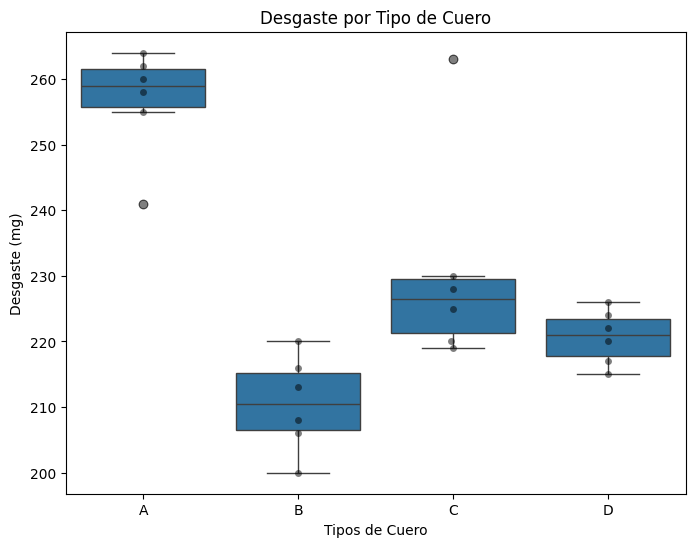

In [6]:
# @title **A. BoxPlot para el DCA en Python**
plt.figure(figsize=(8, 6))
sns.boxplot(x="Tipos de Cuero", y="Desgaste", data=df)
sns.swarmplot(x="Tipos de Cuero", y="Desgaste", data=df, color='black', alpha=0.5)
plt.title('Desgaste por Tipo de Cuero')
plt.xlabel('Tipos de Cuero')
plt.ylabel('Desgaste (mg)')
plt.show()

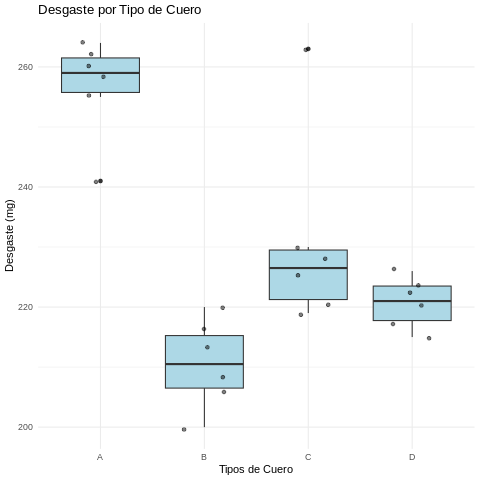

In [7]:
%%R
# @title **B. BoxPlot para el DCA en R**
library(ggplot2)

# Create the boxplot with swarmplot overlay
ggplot(df_r, aes(x = Tipos_de_Cuero, y = Desgaste)) +
  geom_boxplot(fill = "lightblue") + # Add boxplot with fill color
  geom_jitter(width = 0.2, color = "black", alpha = 0.5) + # Add swarmplot (jittered points)
  labs(title = "Desgaste por Tipo de Cuero",
       x = "Tipos de Cuero",
       y = "Desgaste (mg)") +
  theme_minimal() # Use a minimal theme

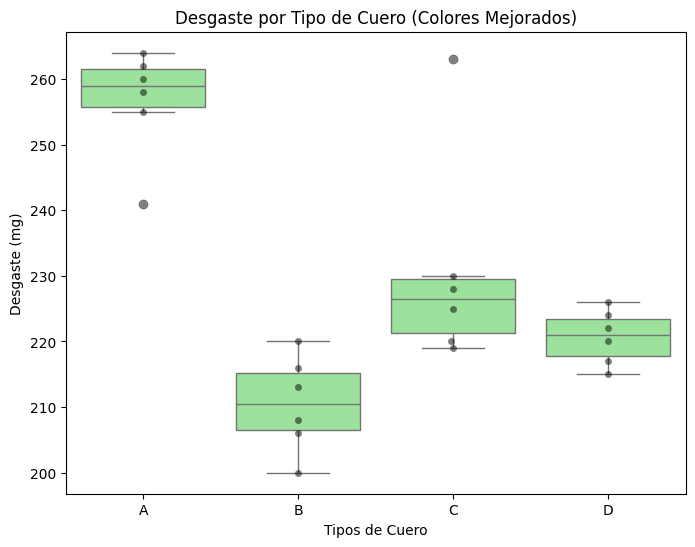

In [8]:
# @title **4. BoxPlot para el Desgaste - Mejorando colores**
plt.figure(figsize=(8, 6))
sns.boxplot(x="Tipos de Cuero", y="Desgaste", data=df, color='lightgreen')  # Cambiar color de las cajas
sns.swarmplot(x="Tipos de Cuero", y="Desgaste", data=df, color='black', alpha=0.5)
plt.title('Desgaste por Tipo de Cuero (Colores Mejorados)')
plt.xlabel('Tipos de Cuero')
plt.ylabel('Desgaste (mg)')
plt.show()

[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **4. Análisis de Varianza (ANOVA)**


In [9]:
# @title **A. Análisis de Varianza (ANOVA) en Python**
modelo_desgaste = ols("Desgaste ~ Q('Tipos de Cuero')", data=df).fit()
anova_desgaste = sm.stats.anova_lm(modelo_desgaste, typ=1)
print(anova_desgaste)

                       df       sum_sq      mean_sq          F    PR(>F)
Q('Tipos de Cuero')   3.0  7072.333333  2357.444444  23.237501  0.000001
Residual             20.0  2029.000000   101.450000        NaN       NaN


+ _La tabla ANOVA descompone la varianza de Desgaste en dos componentes: un componente entre-grupos Q('Tipos de Cuero') y un componente dentro-de-grupos (Residual).  La razón-F, que en este caso es igual a 23,2375, es el cociente entre el estimado entre-grupos y el estimado dentro-de-grupos.  Puesto que el valor-P de la prueba-F es menor que 0,05, existe una diferencia estadísticamente significativa entre la media de Desgaste entre un nivel de TIPOS DE CUERO y otro, con un nivel del 5% de significación.  Para determinar cuáles medias son significativamente diferentes de otras, seleccione Pruebas de Múltiples Rangos, de la lista de Opciones Tabulares._

In [10]:
%%R
# @title **Análisis de Varianza (ANOVA) en R**
# Perform ANOVA
anova_result <- aov(Desgaste ~ Tipos_de_Cuero, data = df_r)

# Print ANOVA summary
summary(anova_result)

               Df Sum Sq Mean Sq F value Pr(>F)    
Tipos_de_Cuero  3   7072  2357.4   23.24  1e-06 ***
Residuals      20   2029   101.4                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [11]:
# @title **6. Análisis de Varianza Tipo II**
# Realizar el ANOVA
model = ols('Desgaste ~ Q("Tipos de Cuero")', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=1)
print(anova_table)

                       df       sum_sq      mean_sq          F    PR(>F)
Q("Tipos de Cuero")   3.0  7072.333333  2357.444444  23.237501  0.000001
Residual             20.0  2029.000000   101.450000        NaN       NaN


In [12]:
%%R
# @title **6. Análisis de Varianza Tipo I en R**
# Perform ANOVA Type I
anova_result_type1 <- aov(Desgaste ~ Tipos_de_Cuero, data = df_r)

# Print ANOVA summary
summary(anova_result_type1)

               Df Sum Sq Mean Sq F value Pr(>F)    
Tipos_de_Cuero  3   7072  2357.4   23.24  1e-06 ***
Residuals      20   2029   101.4                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


[⬆️ Volver al inicio](#inicio)

<a name="T5"></a>
## **5. Resumen del Análisis de Varianza**




In [13]:
# @title **Resumen del Análisis de Varianza**

print(modelo_desgaste.summary())

                            OLS Regression Results                            
Dep. Variable:               Desgaste   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     23.24
Date:                Thu, 11 Sep 2025   Prob (F-statistic):           1.00e-06
Time:                        19:30:40   Log-Likelihood:                -87.301
No. Observations:                  24   AIC:                             182.6
Df Residuals:                      20   BIC:                             187.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [14]:
%%R
# @title **Resumen del Análisis de Varianza en R**

# Print ANOVA summary
summary(anova_result)

               Df Sum Sq Mean Sq F value Pr(>F)    
Tipos_de_Cuero  3   7072  2357.4   23.24  1e-06 ***
Residuals      20   2029   101.4                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


[⬆️ Volver al inicio](#inicio)

<a name="T6"></a>
## **6. Comparaciones Múltiples - Desgaste**


In [15]:
# @title **Comparaciones Múltiples - Desgaste**

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=df['Desgaste'], groups=df['Tipos de Cuero'], alpha=0.05)

# Print the results
print(tukey_result)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     A      B -46.1667    0.0 -62.4431 -29.8903   True
     A      C -25.8333 0.0013 -42.1097  -9.5569   True
     A      D    -36.0    0.0 -52.2764 -19.7236   True
     B      C  20.3333 0.0112   4.0569  36.6097   True
     B      D  10.1667 0.3263  -6.1097  26.4431  False
     C      D -10.1667 0.3263 -26.4431   6.1097  False
------------------------------------------------------


In [16]:
%%R
# @title **Comparaciones Múltiples - Desgaste en R**
# Perform Tukey's HSD post-hoc test
tukey_result_r <- TukeyHSD(anova_result)

# Print the results
print(tukey_result_r)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Desgaste ~ Tipos_de_Cuero, data = df_r)

$Tipos_de_Cuero
         diff        lwr        upr     p adj
B-A -46.16667 -62.443068 -29.890265 0.0000007
C-A -25.83333 -42.109735  -9.556932 0.0013189
D-A -36.00000 -52.276401 -19.723599 0.0000265
C-B  20.33333   4.056932  36.609735 0.0112174
D-B  10.16667  -6.109735  26.443068 0.3263417
D-C -10.16667 -26.443068   6.109735 0.3263417



[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. Descriptores numéricos para 'Desgaste' por 'Tipos de Cuero'**




In [17]:
# @title **Descriptores numéricos para 'Desgaste' por 'Tipos de Cuero'**
print('Desgaste por Tipos de Cuero')
display(df.groupby('Tipos de Cuero')['Desgaste'].agg(['mean', 'std', 'median', 'count']))

Desgaste por Tipos de Cuero


,mean,std,median,count
Tipos de Cuero,,,,
A,256.666667,8.286535,259.0,6
B,210.500000,7.259477,210.5,6
C,230.833333,16.339115,226.5,6
D,220.666667,4.179314,221.0,6


In [18]:
%%R
# @title **Descriptores numéricos para 'Desgaste' por 'Tipos de Cuero' en R**
library(dplyr)

df_r %>%
  group_by(Tipos_de_Cuero) %>%
  summarise(
    mean = mean(Desgaste),
    std = sd(Desgaste),
    median = median(Desgaste),
    count = n()
  )

# A tibble: 4 × 5
  Tipos_de_Cuero  mean   std median count
  <chr>          <dbl> <dbl>  <dbl> <int>
1 A               257.  8.29   259      6
2 B               210.  7.26   210.     6
3 C               231. 16.3    226.     6
4 D               221.  4.18   221      6



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



[⬆️ Volver al inicio](#inicio)

<a name="T8"></a>
## **8. Descriptores numéricos para 'Desgaste' por 'Tipos de Cuero' con Comparaciones Múltiples**

In [19]:
# @title **Descriptores numéricos para 'Desgaste' por 'Tipos de Cuero' con Comparaciones Múltiples**

print('Desgaste por Tipos de Cuero')
display(df.groupby('Tipos de Cuero')['Desgaste'].agg(['mean', 'std', 'median', 'count']))

print("\nTukey's HSD Post-Hoc Test Results:")
print(tukey_result)

Desgaste por Tipos de Cuero


,mean,std,median,count
Tipos de Cuero,,,,
A,256.666667,8.286535,259.0,6
B,210.500000,7.259477,210.5,6
C,230.833333,16.339115,226.5,6
D,220.666667,4.179314,221.0,6



Tukey's HSD Post-Hoc Test Results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     A      B -46.1667    0.0 -62.4431 -29.8903   True
     A      C -25.8333 0.0013 -42.1097  -9.5569   True
     A      D    -36.0    0.0 -52.2764 -19.7236   True
     B      C  20.3333 0.0112   4.0569  36.6097   True
     B      D  10.1667 0.3263  -6.1097  26.4431  False
     C      D -10.1667 0.3263 -26.4431   6.1097  False
------------------------------------------------------


In [20]:
%%R
# @title **Descriptores numéricos para 'Desgaste' por 'Tipos de Cuero' con Comparaciones Múltiples en R**
library(dplyr)

print("Desgaste por Tipos de Cuero:")
df_r %>%
  group_by(Tipos_de_Cuero) %>%
  summarise(
    mean = mean(Desgaste),
    std = sd(Desgaste),
    median = median(Desgaste),
    count = n()
  ) %>%
  print()

print("\nTukey's HSD Post-Hoc Test Results:")
tukey_result_r <- TukeyHSD(anova_result)
print(tukey_result_r)

[1] "Desgaste por Tipos de Cuero:"
# A tibble: 4 × 5
  Tipos_de_Cuero  mean   std median count
  <chr>          <dbl> <dbl>  <dbl> <int>
1 A               257.  8.29   259      6
2 B               210.  7.26   210.     6
3 C               231. 16.3    226.     6
4 D               221.  4.18   221      6
[1] "\nTukey's HSD Post-Hoc Test Results:"
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Desgaste ~ Tipos_de_Cuero, data = df_r)

$Tipos_de_Cuero
         diff        lwr        upr     p adj
B-A -46.16667 -62.443068 -29.890265 0.0000007
C-A -25.83333 -42.109735  -9.556932 0.0013189
D-A -36.00000 -52.276401 -19.723599 0.0000265
C-B  20.33333   4.056932  36.609735 0.0112174
D-B  10.16667  -6.109735  26.443068 0.3263417
D-C -10.16667 -26.443068   6.109735 0.3263417



[⬆️ Volver al inicio](#inicio)

<a name="T9"></a>
## **9. HSD de Tukey Grafico para la diferencia de Medias**


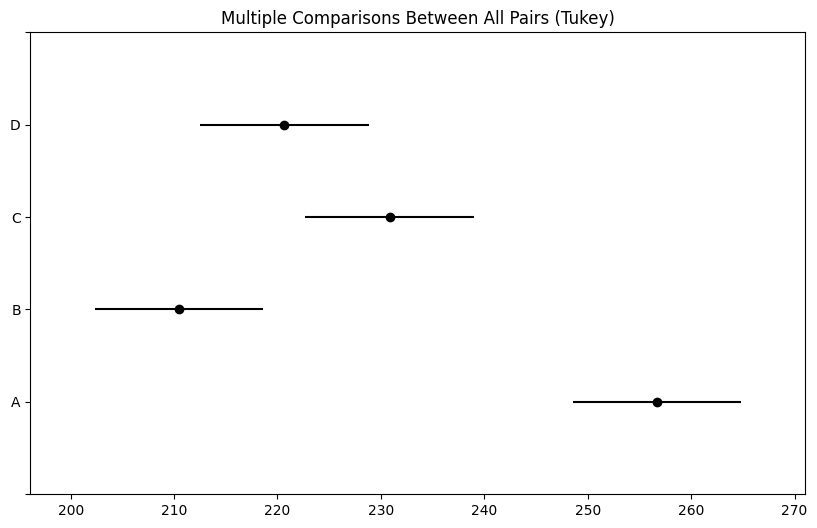

group1,group2,meandiff,p-adj,lower,upper,reject
A,B,-46.1667,0.0,-62.4431,-29.8903,True
A,C,-25.8333,0.0013,-42.1097,-9.5569,True
A,D,-36.0,0.0,-52.2764,-19.7236,True
B,C,20.3333,0.0112,4.0569,36.6097,True
B,D,10.1667,0.3263,-6.1097,26.4431,False
C,D,-10.1667,0.3263,-26.4431,6.1097,False


In [21]:
# @title **HSD de Tukey Grafico para la diferencia de Medias**
tukey = pairwise_tukeyhsd(endog=df["Desgaste"],     # Data
                          groups=df["Tipos de Cuero"],   # Groups
                          alpha=0.05)          # Significance level

tukey.plot_simultaneous()    # Plot group confidence intervals
plt.show()

tukey.summary()

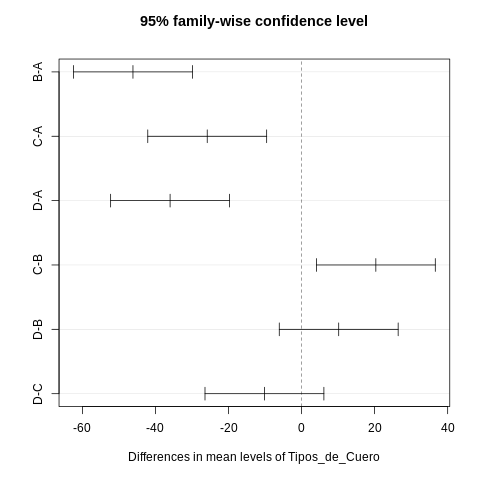

In [22]:
%%R
# @title **HSD de Tukey Grafico para la diferencia de Medias en R**
# Plot the Tukey HSD results
plot(tukey_result_r)

[⬆️ Volver al inicio](#inicio)

<a name="T10"></a>
## **10. HSD de Tukey Grafico Vertical para la diferencia de Medias**




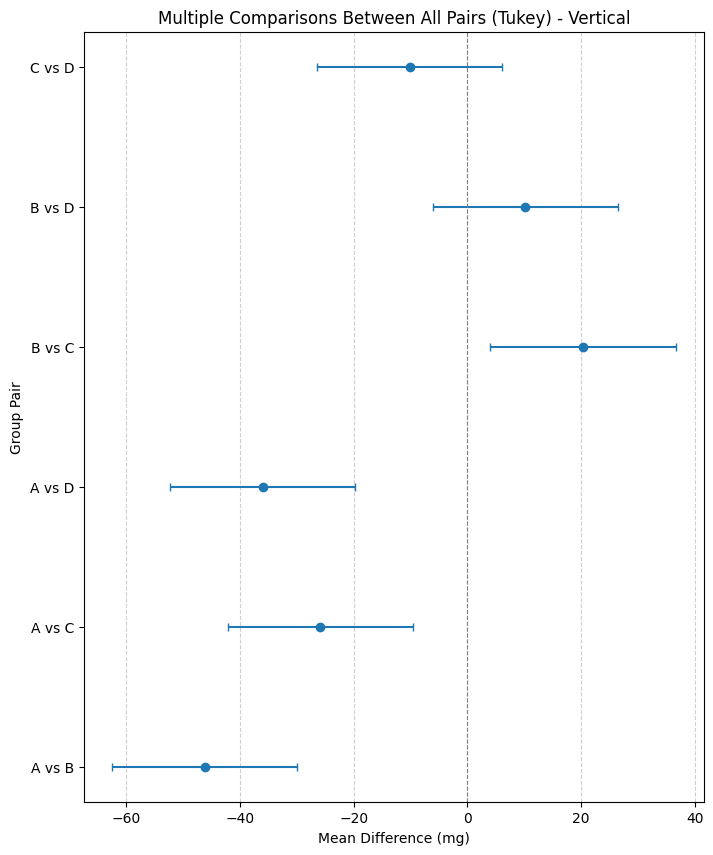

In [23]:
# @title **HSD de Tukey Grafico Vertical para la diferencia de Medias**

# Get the data from the Tukey HSD result
tukey_data = pd.DataFrame(tukey_result._results_table.data[1:], columns=tukey_result._results_table.data[0])

# Create a new column for the mean difference and its confidence interval
tukey_data['mean_diff_ci'] = tukey_data.apply(lambda row: f"{row['meandiff']:.2f} ({row['lower']:.2f}, {row['upper']:.2f})", axis=1)

# Create a categorical type for the group pairs to maintain order in the plot
tukey_data['group_pair'] = tukey_data['group1'] + ' vs ' + tukey_data['group2']

# Plotting
plt.figure(figsize=(8, 10)) # Adjust figure size for vertical plot
plt.errorbar(x=tukey_data['meandiff'], y=tukey_data['group_pair'], xerr=[tukey_data['meandiff'] - tukey_data['lower'], tukey_data['upper'] - tukey_data['meandiff']], fmt='o', capsize=3)

# Add a vertical line at 0 for reference
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

plt.title('Multiple Comparisons Between All Pairs (Tukey) - Vertical')
plt.xlabel('Mean Difference (mg)')
plt.ylabel('Group Pair')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

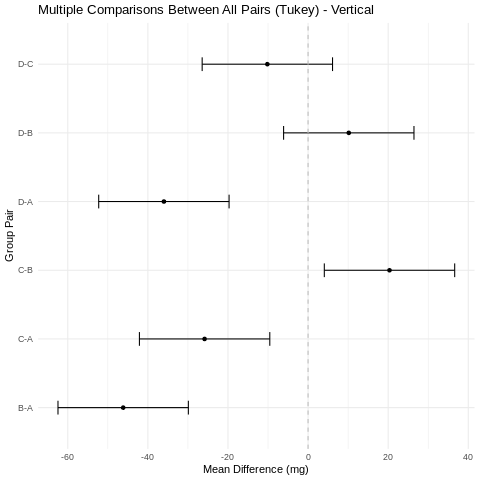

In [24]:
%%R
# @title **HSD de Tukey Grafico Vertical para la diferencia de Medias en R**
library(ggplot2)
library(dplyr)

# Convert Tukey HSD results to a dataframe
tukey_df <- as.data.frame(tukey_result_r$Tipos_de_Cuero)
tukey_df$pair <- rownames(tukey_df)

# Create the vertical plot
ggplot(tukey_df, aes(x = diff, y = pair)) +
  geom_point() +
  geom_errorbarh(aes(xmin = lwr, xmax = upr), height = 0.2) +
  geom_vline(xintercept = 0, color = "grey", linetype = "dashed") +
  labs(title = "Multiple Comparisons Between All Pairs (Tukey) - Vertical",
       x = "Mean Difference (mg)",
       y = "Group Pair") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1)) # Ensure y-axis labels are horizontal

[⬆️ Volver al inicio](#inicio)

<a name="T11"></a>
## **11. Shapiro Wilks para Desgaste en R y Python**


In [25]:
%%R
# @title **11. Shapiro Wilks para Desgaste en R**
# Perform Shapiro-Wilk test on the residuals
shapiro_result <- shapiro.test(residuals(anova_result))

# Print the results
print(paste("El estadistico de Prueba para shapiro wilks w =", shapiro_result$statistic))
print(paste("El valor p para el estadistico de prueba es p_value =", shapiro_result$p.value))
print(paste("Para que se cumpla el supuesto de normalidad se debe cumplir que p_value =", shapiro_result$p.value > 0.05))

[1] "El estadistico de Prueba para shapiro wilks w = 0.878119423905725"
[1] "El valor p para el estadistico de prueba es p_value = 0.0076182402268792"
[1] "Para que se cumpla el supuesto de normalidad se debe cumplir que p_value = FALSE"


In [26]:
# @title **11. Shapiro Wilks para Desgaste en Python**
from scipy import stats

# Perform Shapiro-Wilk test on the residuals
shapiro_result_py = stats.shapiro(modelo_desgaste.resid)
w, p_value = shapiro_result_py

# Print the results
print('El estadistico de Prueba para shapiro wilks w =', w)
print('El valor p para el estadistico de prueba es p_value =', p_value)
print('Para que se cumpla el supuesto de normalidad se debe cumplir que p_value =', p_value > 0.05)

El estadistico de Prueba para shapiro wilks w = 0.8781194237526648
El valor p para el estadistico de prueba es p_value = 0.007618240172874149
Para que se cumpla el supuesto de normalidad se debe cumplir que p_value = False


[⬆️ Volver al inicio](#inicio)

<a name="T12"></a>
## **12. Gráfico de Probabilidad Normal y Histograma para los Residuos en Python**


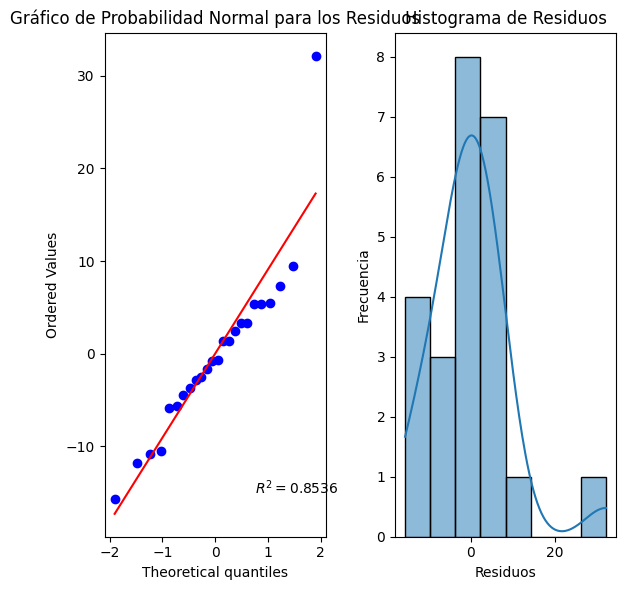

In [28]:
# @title **A. Gráfico de Probabilidad Normal y Histograma para los Residuos en Python**

# Normal Probability Plot
fig = plt.figure(figsize= (6, 6))
ax1 = fig.add_subplot(121)
stats.probplot(modelo_desgaste.resid, plot=ax1, rvalue=True)
ax1.set_title("Gráfico de Probabilidad Normal para los Residuos")

# Histogram of Residuals
ax2 = fig.add_subplot(122)
sns.histplot(modelo_desgaste.resid, kde=True, ax=ax2)
ax2.set_title("Histograma de Residuos")
ax2.set_xlabel("Residuos")
ax2.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

[⬆️ Volver al inicio](#inicio)

<a name="T13"></a>
## **13. Comparaciones Multiples de Medias para el Factor Principal - Intervalos de Confianza**


,Tipos de Cuero,Desgaste
0,A,264
1,A,260
2,A,258
3,A,241
4,A,262
5,A,255
6,B,208
7,B,220
8,B,216
9,B,200


/tmp/ipython-input-4143859325.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot(x="Tipos de Cuero", y="Desgaste", data=df, ci=95, capsize=0.1, join=False)
/tmp/ipython-input-4143859325.py:21: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x="Tipos de Cuero", y="Desgaste", data=df, ci=95, capsize=0.1, join=False)


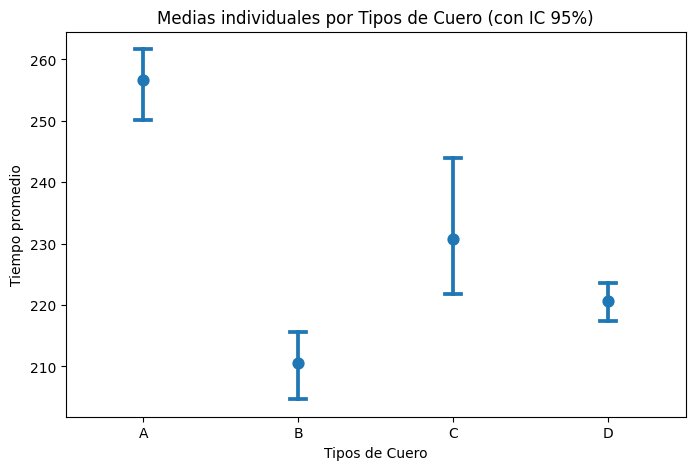

In [29]:
# @title **A. Gráfico de medias individuales en Python**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# @title **A. DataFrame en Python**
data = {'Tipos de Cuero': ['A'] * 6 + ['B'] * 6 + ['C'] * 6 + ['D'] * 6,
        'Desgaste': [264, 260, 258, 241, 262, 255,
                     208, 220, 216, 200, 213, 206,
                     220, 263, 219, 225, 230, 228,
                     217, 226, 215, 224, 220, 222]}

df = pd.DataFrame(data)
display(df)



# Gráfico de medias con IC 95%
plt.figure(figsize=(8,5))
sns.pointplot(x="Tipos de Cuero", y="Desgaste", data=df, ci=95, capsize=0.1, join=False)

plt.title("Medias individuales por Tipos de Cuero (con IC 95%)")
plt.ylabel("Tiempo promedio")
plt.show()


[⬆️ Volver al inicio](#inicio)

<a name="T14"></a>
## **14. Comparaciones Multiples de Medias para el Factor Principal - Intervalos de Confianza - HSD**


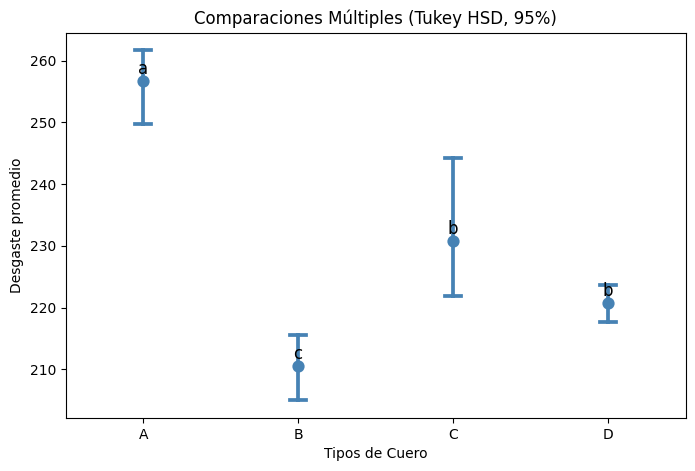

In [35]:
# @title **A. Código en Python (gráfico adaptado a Tukey HSD)**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Gráfico de medias
plt.figure(figsize=(8,5))

ax = sns.pointplot(x="Tipos de Cuero", y="Desgaste", data=df, errorbar=('ci', 95), capsize=0.1, linestyle='none', color="steelblue")

plt.title("Comparaciones Múltiples (Tukey HSD, 95%)")
plt.ylabel("Desgaste promedio")


grupos = {"A": "a", "B": "c", "C": "b", "D": "b"}


# Añadir letras encima de cada media
medias = df.groupby("Tipos de Cuero")["Desgaste"].mean()
for i, cat in enumerate(medias.index):
    plt.text(i, medias[cat] + 0.5, grupos[cat],
             ha='center', va='bottom', fontsize=12, color="black")

plt.show()

In [36]:
# @title **B. Comparaciones Múltiples (Tukey HSD) en formato tabular**

# Get the Tukey HSD results
tukey_result = pairwise_tukeyhsd(endog=df['Desgaste'], groups=df['Tipos de Cuero'], alpha=0.05)

# Convert the results to a pandas DataFrame for better formatting
tukey_table = pd.DataFrame(data=tukey_result._results_table.data[1:], columns=tukey_result._results_table.data[0])

# Display the table
print("Comparaciones Múltiples (Tukey HSD):")
display(tukey_table)

Comparaciones Múltiples (Tukey HSD):


,group1,group2,meandiff,p-adj,lower,upper,reject
0,A,B,-46.1667,0.0000,-62.4431,-29.8903,True
1,A,C,-25.8333,0.0013,-42.1097,-9.5569,True
2,A,D,-36.0000,0.0000,-52.2764,-19.7236,True
3,B,C,20.3333,0.0112,4.0569,36.6097,True
4,B,D,10.1667,0.3263,-6.1097,26.4431,False
5,C,D,-10.1667,0.3263,-26.4431,6.1097,False


[⬆️ Volver al inicio](#inicio)

<a name="T15"></a>
## **15. Diferencia clave entre Tukey HSD y Fisher LSD**





## 🔹 **A. Diferencia clave entre** _**Tukey HSD**_ y **Fisher LSD**

* **Tukey HSD** es más conservador: controla mejor el error tipo I cuando se hacen muchas comparaciones.
* **Fisher LSD** es más **liberal**: permite detectar más diferencias, pero con mayor riesgo de falsos positivos.
* En la práctica: **los grupos homogéneos con LSD suelen ser más pequeños**, porque LSD declara más pares como significativamente distintos.

---

## 🔹 **B. Pasos para adaptar el gráfico al método LSD**

1. Se calcula la **diferencia mínima significativa (LSD)** a partir del ANOVA:

$$
LSD = t_{\alpha/2, df_{error}} \cdot \sqrt{2 \cdot \frac{MS_{error}}{n}}
$$

donde:

* $t_{\alpha/2, df_{error}}$ es el valor crítico de la t de Student.
* $MS_{error}$ es el cuadrado medio del error del ANOVA.
* $n$ es el tamaño de muestra por grupo (aquí, 5).

2. Se comparan todas las diferencias de medias contra ese **LSD crítico**.
3. Se forman los **grupos homogéneos LSD** (pueden diferir de los que dio Tukey).


/tmp/ipython-input-57965295.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.pointplot(x="Tipos de Cuero", y="Desgaste", data=df,
/tmp/ipython-input-57965295.py:9: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x="Tipos de Cuero", y="Desgaste", data=df,


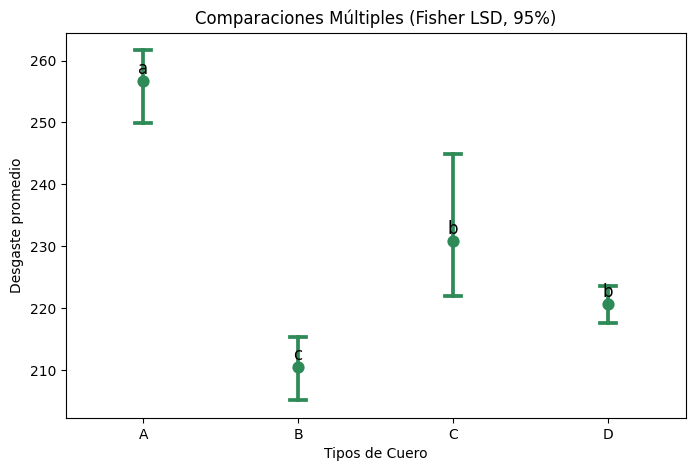

In [38]:
# @title **C. Gráfico adaptado a LSD en Python**
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Gráfico de medias
plt.figure(figsize=(8,5))
ax = sns.pointplot(x="Tipos de Cuero", y="Desgaste", data=df,
                   ci=95, capsize=0.1, join=False, color="seagreen")

plt.title("Comparaciones Múltiples (Fisher LSD, 95%)")
plt.ylabel("Desgaste promedio")

# Grupos homogéneos (ejemplo adaptado a LSD: más diferencias detectadas)

grupos = {"A": "a", "B": "c", "C": "b", "D": "b"}

# Añadir letras encima de cada media
medias = df.groupby("Tipos de Cuero")["Desgaste"].mean()
for i, cat in enumerate(medias.index):
    plt.text(i, medias[cat] + 0.5, grupos[cat],
             ha='center', va='bottom', fontsize=12, color="black")

plt.show()


In [39]:
# @title **D. Comparaciones Múltiples (Fisher's LSD) en formato tabular**
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.anova import anova_lm
from scipy import stats
import numpy as np
import pandas as pd

# Perform ANOVA to get the mean square error and degrees of freedom
modelo_desgaste = ols("Desgaste ~ C(Q('Tipos de Cuero'))", data=df).fit()
anova_table = anova_lm(modelo_desgaste, typ=1)
ms_error = anova_table['mean_sq']['Residual']
df_error = anova_table['df']['Residual']

# Calculate Fisher's LSD
alpha = 0.05
n_groups = df['Tipos de Cuero'].nunique()
n_per_group = df.groupby('Tipos de Cuero')['Desgaste'].count().iloc[0] # Assuming equal sample sizes
t_critical = stats.t.ppf(1 - alpha / 2, df_error)
lsd = t_critical * np.sqrt(2 * ms_error / n_per_group)

# Perform pairwise t-tests and store results
group_names = df['Tipos de Cuero'].unique()
comparisons = []
for i in range(len(group_names)):
    for j in range(i + 1, len(group_names)):
        group1 = group_names[i]
        group2 = group_names[j]
        group1_data = df[df['Tipos de Cuero'] == group1]['Desgaste']
        group2_data = df[df['Tipos de Cuero'] == group2]['Desgaste']
        mean_diff = group1_data.mean() - group2_data.mean()
        t_stat, p_value = stats.ttest_ind(group1_data, group2_data, equal_var=True) # Assuming equal variances based on ANOVA assumption

        # Determine if significantly different based on LSD
        reject_lsd = abs(mean_diff) > lsd
        # Determine if significantly different based on p-value
        reject_pvalue = p_value < alpha

        comparisons.append({
            'group1': group1,
            'group2': group2,
            'meandiff': mean_diff,
            'lsd': lsd,
            'significant_lsd': reject_lsd,
            'p_value_ttest': p_value,
            'significant_pvalue': reject_pvalue
        })

# Create a DataFrame from the comparisons
lsd_table = pd.DataFrame(comparisons)

# Display the table
print("Comparaciones Múltiples (Fisher's LSD):")
display(lsd_table)

Comparaciones Múltiples (Fisher's LSD):


,group1,group2,meandiff,lsd,significant_lsd,p_value_ttest,significant_pvalue
0,A,B,46.166667,12.130315,True,0.000001,True
1,A,C,25.833333,12.130315,True,0.006184,True
2,A,D,36.000000,12.130315,True,0.000003,True
3,B,C,-20.333333,12.130315,True,0.019261,True
4,B,D,-10.166667,12.130315,False,0.013975,True
5,C,D,10.166667,12.130315,False,0.170565,False


[⬆️ Volver al inicio](#inicio)

<a name="T16"></a>
## **16. **
